# Statistiques escriptives sur les données électorales et socio-économiques

In [1]:
import pandas as pd
import numpy as np
import openpyxl
import glob
import os
import zipfile
import requests
import io
import matplotlib.pyplot as plt
import seaborn as sns
from zipfile import ZipFile
from io import BytesIO

Import des données

In [ ]:
data = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\données_caracteristiques_communes.csv", index_col=0)
data['codecommune'] = data['codecommune'].astype(str).str.zfill(5)


data.head()

C:\Users\yancr\AppData\Local\Temp\ipykernel_28596\184722120.py:1: DtypeWarning: Columns (0: Annee) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\données_caracteristiques_communes.csv", index_col=0)


,codecommune,Annee,pop,propf,prop014,prop1539,prop4059,prop60p,petranger,pcapi,...,pbac,psup,revmoy,abstention_pres,vote_RN_pres,vote_PS_pres,abstention_leg,vote_RN_leg,vote_PS_leg,typologie_urbaine
0,01001,1995,662,0.471756,0.268702,0.280916,0.258015,0.192366,0.016320,0.294118,...,0.0,0.073113,12110.340,0.201285,0.225352,0.247887,NaN,NaN,NaN,Rural non périurbain
1,01001,1996,678,0.468657,0.270149,0.270149,0.265672,0.194030,0.017366,0.297521,...,0.0,0.075688,11530.236,NaN,NaN,NaN,NaN,NaN,NaN,Rural non périurbain
2,01001,1997,695,0.467930,0.272595,0.259475,0.271137,0.196793,0.016997,0.298387,...,0.0,0.080357,12207.807,NaN,NaN,NaN,0.337607,0.20068,0.316327,Rural non périurbain
3,01001,1998,711,0.465714,0.272857,0.250000,0.278571,0.198571,0.018006,0.305882,...,0.0,0.082429,12892.058,NaN,NaN,NaN,NaN,NaN,NaN,Rural non périurbain
4,01001,1999,728,0.463687,0.273743,0.240223,0.284916,0.201117,0.018945,0.307692,...,0.0,0.084746,12839.338,NaN,NaN,NaN,NaN,NaN,NaN,Rural non périurbain


## Données électorales

### Evolution du vote FN/RN aux élections présidentielles selon le type de communes (1995-2022)

In [3]:
data_pres = data[data['Annee'].isin([1995,2002,2007,2012,2017,2022])]

In [4]:
data_pres.columns

Index(['codecommune', 'Annee', 'pop', 'propf', 'prop014', 'prop1539',
       'prop4059', 'prop60p', 'petranger', 'pcapi', 'pouem', 'paind', 'pchom',
       'pbac', 'psup', 'revmoy', 'abstention_pres', 'vote_RN_pres',
       'vote_PS_pres', 'abstention_leg', 'vote_RN_leg', 'vote_PS_leg',
       'typologie_urbaine'],
      dtype='str')

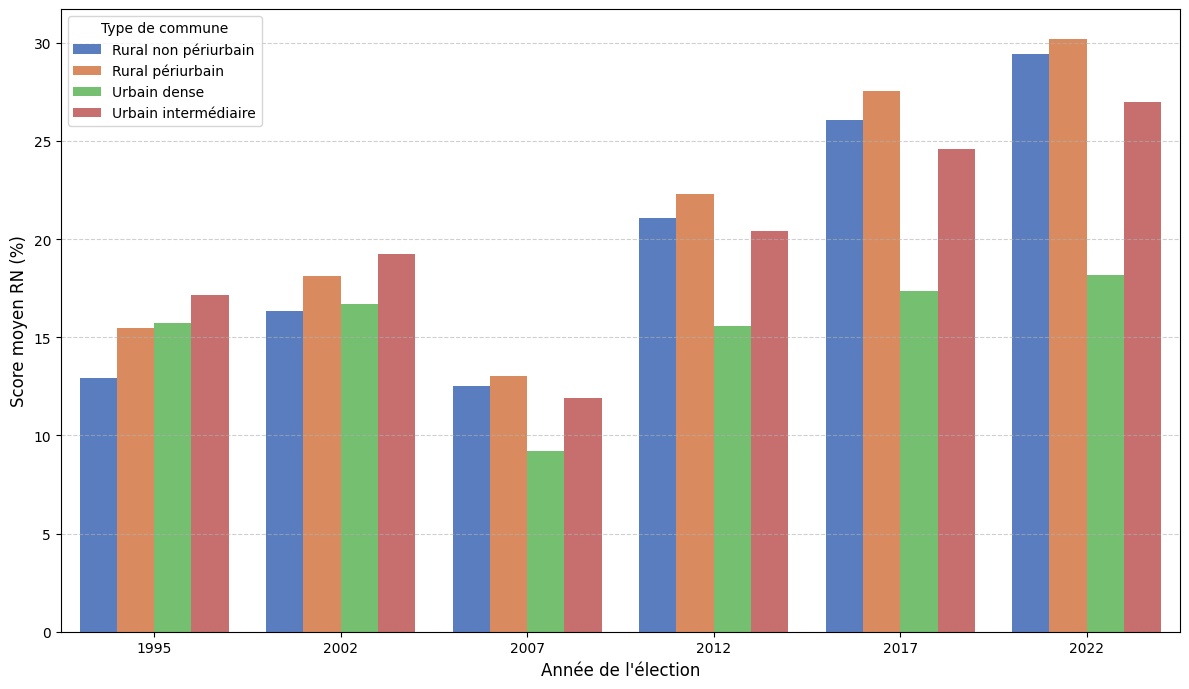

In [5]:
# 1. Préparation des données : calcul de la moyenne du score RN par année et par typologie
df_bar = data_pres.groupby(['Annee', 'typologie_urbaine'])['vote_RN_pres'].mean().reset_index()

# Conversion en pourcentages (multiplication par 100)
df_bar['vote_RN_pres'] = df_bar['vote_RN_pres'] * 100

# 2. Création du graphique en barres verticales
plt.figure(figsize=(12, 7))
sns.barplot(
    data=df_bar, 
    x='Annee', 
    y='vote_RN_pres', 
    hue='typologie_urbaine', 
    palette='muted' # Palette de couleurs distinctes
)

# 3. Personnalisation du rendu
#plt.title("Évolution du score moyen du RN par typologie de commune", fontsize=14, fontweight='bold', pad=20)
plt.ylabel("Score moyen RN (%)", fontsize=12)
plt.xlabel("Année de l'élection", fontsize=12)

# Déplacement de la légende à l'intérieur du graphique
# loc='upper left' la place en haut à gauche. Vous pouvez aussi utiliser loc='best' pour un placement automatique.
plt.legend(title="Type de commune", loc='upper left')

# Ajout d'une grille horizontale pour faciliter la lecture des scores
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Evolution du vote FN/RN aux élections législatives selon le type de communes (1997-2022)

In [6]:
data_leg = data[data['Annee'].isin([1997,2002,2007,2012,2017,2022])]

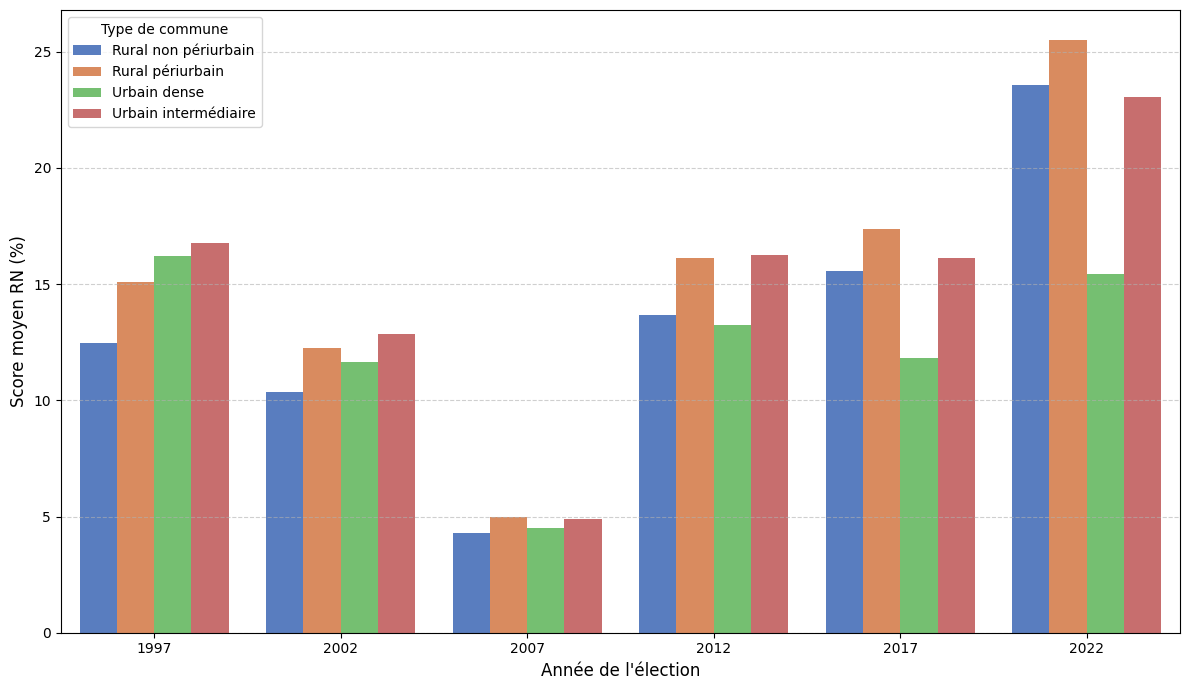

In [7]:
# 1. Préparation des données : calcul de la moyenne du score RN par année et par typologie
df_bar = data_leg.groupby(['Annee', 'typologie_urbaine'])['vote_RN_leg'].mean().reset_index()

# Conversion en pourcentages (multiplication par 100)
df_bar['vote_RN_leg'] = df_bar['vote_RN_leg'] * 100

# 2. Création du graphique en barres verticales
plt.figure(figsize=(12, 7))
sns.barplot(
    data=df_bar, 
    x='Annee', 
    y='vote_RN_leg', 
    hue='typologie_urbaine', 
    palette='muted' # Palette de couleurs distinctes
)

# 3. Personnalisation du rendu
#plt.title("Évolution du score moyen du RN par typologie de commune", fontsize=14, fontweight='bold', pad=20)
plt.ylabel("Score moyen RN (%)", fontsize=12)
plt.xlabel("Année de l'élection", fontsize=12)

# Déplacement de la légende à l'intérieur du graphique
# loc='upper left' la place en haut à gauche. Vous pouvez aussi utiliser loc='best' pour un placement automatique.
plt.legend(title="Type de commune", loc='upper left')

# Ajout d'une grille horizontale pour faciliter la lecture des scores
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Données socio-économiques

In [8]:
data_se = data[data['Annee'].isin([1995,1997,2002,2007,2012,2017,2022])]

Evolution des CSP

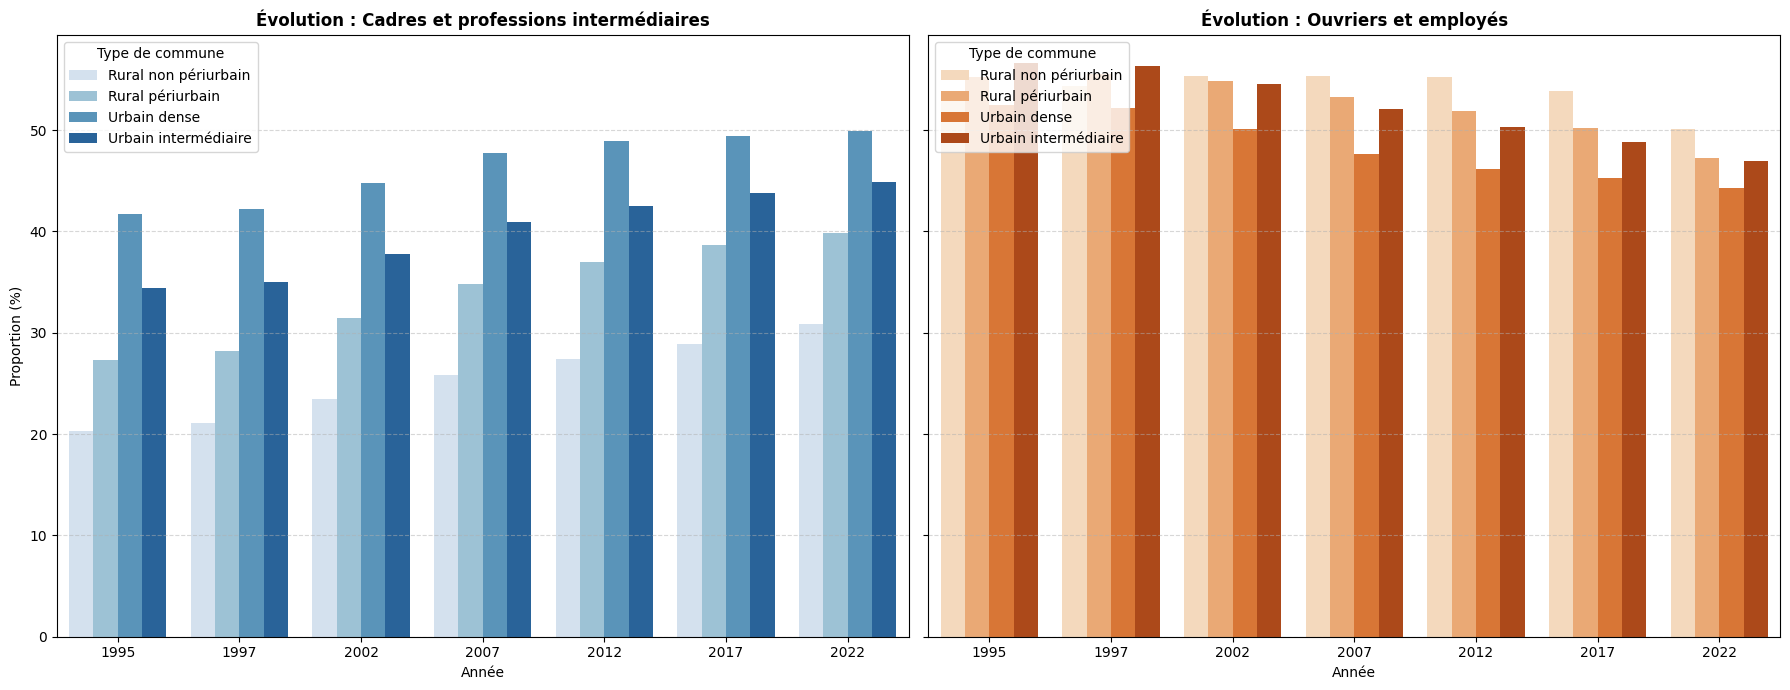

In [9]:
# 1. Préparation des données (correction du groupby avec doubles crochets)
df_bar = data_se.groupby(['Annee', 'typologie_urbaine'])[['pcapi', 'pouem']].mean().reset_index()

# Conversion en pourcentages (multiplication par 100 pour les deux colonnes)
df_bar[['pcapi', 'pouem']] = df_bar[['pcapi', 'pouem']] * 100

# 2. Création de la figure avec deux sous-graphiques côte à côte
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

# --- Graphique 1 : Cadres & Professions Intermédiaires ---
sns.barplot(
    data=df_bar, 
    x='Annee', 
    y='pcapi', 
    hue='typologie_urbaine', 
    palette='Blues', 
    ax=ax1
)
ax1.set_title("Évolution : Cadres et professions intermédiaires", fontsize=12, fontweight='bold')
ax1.set_ylabel("Proportion (%)")
ax1.set_xlabel("Année")
# Légende à l'intérieur en haut à gauche
ax1.legend(title="Type de commune", loc='upper left')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# --- Graphique 2 : Ouvriers ---
sns.barplot(
    data=df_bar, 
    x='Annee', 
    y='pouem', 
    hue='typologie_urbaine', 
    palette='Oranges', 
    ax=ax2
)
ax2.set_title("Évolution : Ouvriers et employés", fontsize=12, fontweight='bold')
ax2.set_ylabel("") # On enlève le label car sharey=True
ax2.set_xlabel("Année")
# Légende à l'intérieur en haut à gauche
ax2.legend(title="Type de commune", loc='upper left')
ax2.grid(axis='y', linestyle='--', alpha=0.5)

#plt.suptitle("Évolution des CSP par typologie de commune", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Evolution du revenu moyen

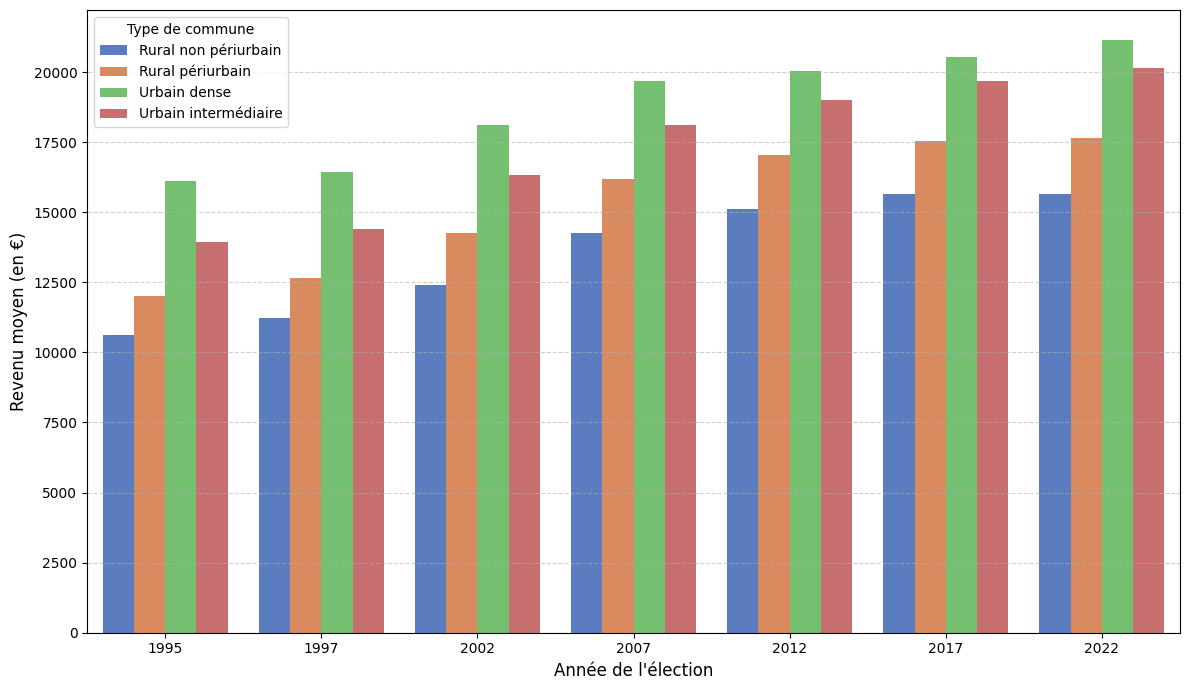

In [10]:
# 1. Préparation des données : calcul du revenu moyen par année et par typologie
# On suppose que votre colonne de catégorie s'appelle 'typologie'
df_bar = data_se.groupby(['Annee', 'typologie_urbaine'])['revmoy'].mean().reset_index()

# 2. Création du graphique en barres verticales
plt.figure(figsize=(12, 7))
sns.barplot(
    data=df_bar, 
    x='Annee', 
    y='revmoy', 
    hue='typologie_urbaine', 
    palette='muted' # Palette de couleurs distinctes
)

# 3. Personnalisation du rendu
#plt.title("Évolution du revenu moyen par typologie de commune", fontsize=14, fontweight='bold', pad=20)
plt.ylabel("Revenu moyen (en €)", fontsize=12)
plt.xlabel("Année de l'élection", fontsize=12)
plt.legend(title="Type de commune", loc='upper left')

# Ajout d'une grille horizontale pour faciliter la lecture des scores
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [11]:
data.columns

Index(['codecommune', 'Annee', 'pop', 'propf', 'prop014', 'prop1539',
       'prop4059', 'prop60p', 'petranger', 'pcapi', 'pouem', 'paind', 'pchom',
       'pbac', 'psup', 'revmoy', 'abstention_pres', 'vote_RN_pres',
       'vote_PS_pres', 'abstention_leg', 'vote_RN_leg', 'vote_PS_leg',
       'typologie_urbaine'],
      dtype='str')

In [12]:
data[['pcapi', 'pouem', 'paind', 'pchom']].head()

,pcapi,pouem,paind,pchom
0,0.294118,0.546219,0.159664,0.046218
1,0.297521,0.549587,0.152893,0.049587
2,0.298387,0.552419,0.149194,0.052419
3,0.305882,0.552941,0.141176,0.058824
4,0.307692,0.553846,0.138462,0.061538


In [13]:
pip install tabulate

Note: you may need to restart the kernel to use updated packages.


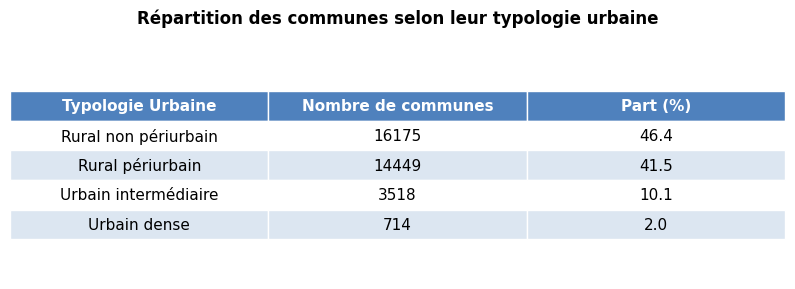

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Calcul des données (exactement comme avant)
# (Assure-toi que ton DataFrame s'appelle bien 'df')
resume = data.groupby('typologie_urbaine')['codecommune'].nunique().reset_index()
resume.columns = ['Typologie Urbaine', 'Nombre de communes']
resume = resume.sort_values(by='Nombre de communes', ascending=False)

# Ajout du pourcentage pour faire plus complet
total = resume['Nombre de communes'].sum()
resume['Part (%)'] = (resume['Nombre de communes'] / total * 100).round(1)

# 2. Configuration de la figure Matplotlib
fig, ax = plt.subplots(figsize=(8, 3)) # Taille à ajuster selon tes préférences
ax.axis('tight')
ax.axis('off') # On cache le graphique de fond

# 3. Préparation des données pour la fonction table()
donnees_tableau = [resume.columns.tolist()] + resume.values.tolist()

# 4. Création du tableau
table = ax.table(cellText=donnees_tableau, 
                 loc='center', 
                 cellLoc='center')

# 5. Design : Rendre le tableau "propre" pour le rapport
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8) # Espacement des cellules (largeur, hauteur)

# Boucle pour colorer l'en-tête et alterner la couleur des lignes
for (i, j), cell in table.get_celld().items():
    if i == 0:
        # En-tête : Fond bleu gris (style académique/pro), texte blanc et gras
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#4F81BD')
    elif i % 2 == 0:
        # Lignes paires : gris/bleu très clair
        cell.set_facecolor('#DCE6F1')
    else:
        # Lignes impaires : blanc
        cell.set_facecolor('white')
        
    # Bordures douces
    cell.set_edgecolor('white')

# 6. Sauvegarde en Haute Résolution (300 dpi pour l'impression/PDF)
plt.title("Répartition des communes selon leur typologie urbaine", pad=20, weight='bold')
plt.tight_layout()
plt.savefig("tableau_typologie_rapport.png", dpi=300, bbox_inches='tight')

# Affichage dans ton interface (Jupyter, etc.)
plt.show()

## Nombres de fermetures par ans par typologie de commune

In [18]:
data_social

,codeCommuneEtablissement,Annee,Hôtels et hébergement,Campings,Restauration traditionnelle,Débits de boissons,Librairie,Presse et papeterie
0,80808,1995,0.0,1.0,0.0,2.0,0.0,0.0
1,80808,1996,0.0,1.0,0.0,2.0,0.0,0.0
2,80808,1997,0.0,1.0,0.0,2.0,0.0,0.0
3,80808,1998,0.0,1.0,0.0,2.0,0.0,0.0
4,80808,1999,0.0,0.0,0.0,2.0,0.0,0.0
...,...,...,...,...,...,...,...,...
784583,02649,2018,0.0,0.0,0.0,0.0,0.0,0.0
784584,02649,2019,0.0,0.0,0.0,0.0,0.0,0.0
784585,02649,2020,0.0,0.0,0.0,0.0,0.0,0.0
784586,02649,2021,0.0,0.0,0.0,0.0,0.0,0.0


In [20]:
# Social
df_rnp = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_rnp.csv", index_col=0)
df_rnp['codecommune'] = df_rnp['codecommune'].astype(str).str.zfill(5)

df_rp = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_rp.csv", index_col=0)
df_rp['codecommune'] = df_rp['codecommune'].astype(str).str.zfill(5)

df_ui = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_ui.csv", index_col=0)
df_ui['codecommune'] = df_ui['codecommune'].astype(str).str.zfill(5)

df_ud = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_d.csv", index_col=0)
df_ud['codecommune'] = df_ud['codecommune'].astype(str).str.zfill(5)

C:\Users\yancr\AppData\Local\Temp\ipykernel_28596\2641705729.py:2: DtypeWarning: Columns (0: Annee) have mixed types. Specify dtype option on import or set low_memory=False.
  df_rnp = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_rnp.csv", index_col=0)
C:\Users\yancr\AppData\Local\Temp\ipykernel_28596\2641705729.py:5: DtypeWarning: Columns (0: Annee) have mixed types. Specify dtype option on import or set low_memory=False.
  df_rp = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_rp.csv", index_col=0)
C:\Users\yancr\AppData\Local\Temp\ipykernel_28596\2641705729.py:8: DtypeWarning: Columns (0: Annee) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ui = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_ui.csv", index_col=0)


In [ ]:
import matplotlib.pyplot as plt

def evol_typo(df):
    # On filtre pour ne garder que les années 1998 à 2022
    df_filtre = df[(df['Annee'] >= 1998) & (df['Annee'] <= 2022)]
    
    # On groupe par année et on somme les deux colonnes d'un coup
    sommes_annuelles = df_filtre.groupby('Annee')[['total_equipements', 'pop']].sum()
    
    # On calcule le ratio : (total équipements) / (population totale)
    ratio_par_hab = sommes_annuelles['total_equipements'] / sommes_annuelles['pop']

    # Création du graphique
    plt.plot(ratio_par_hab.index, ratio_par_hab.values, label='Équipements par habitant', color='#D9534F', linewidth=2)
    plt.title(f"Évolution du nombre d'équipements par habitant dans les communes {}", pad=15)
    plt.xlabel("Année")
    plt.ylabel("Ratio (Équipements / Habitant)")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.show()

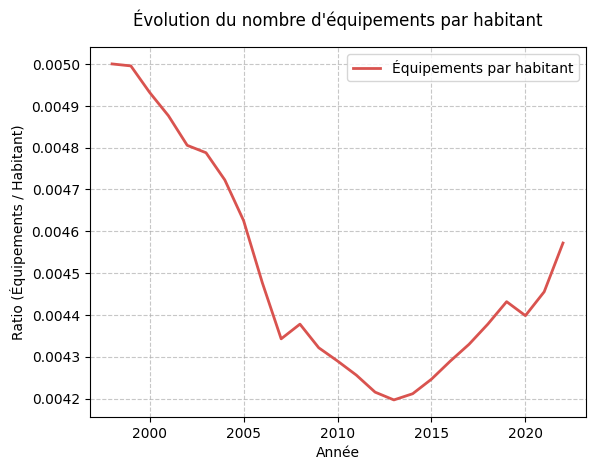

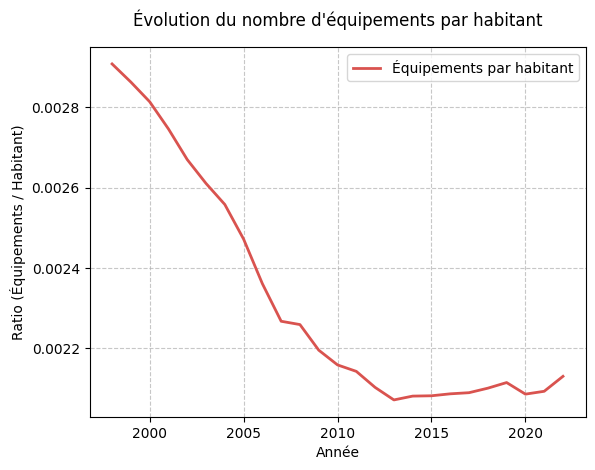

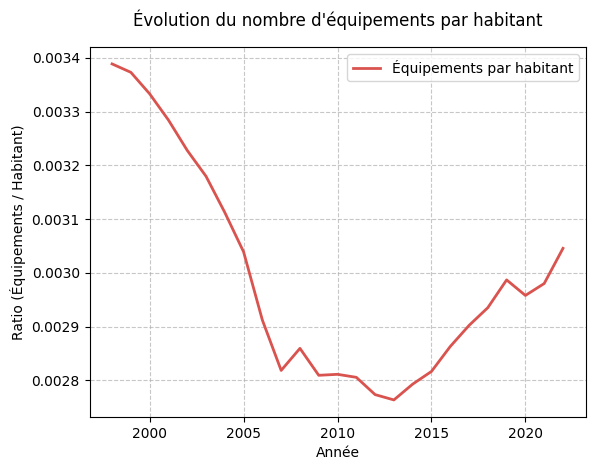

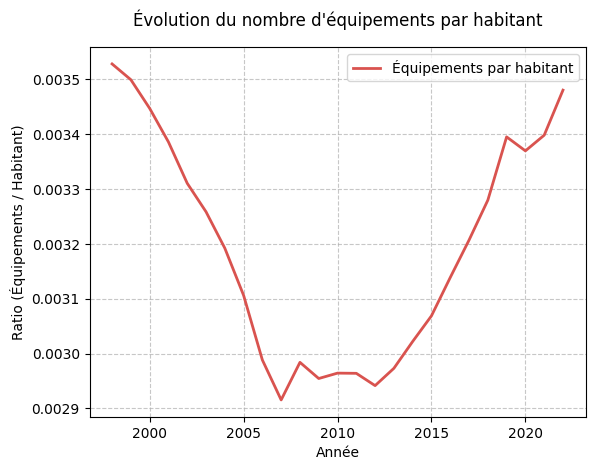

In [39]:
evol_typo(df_rnp)
evol_typo(df_rp)
evol_typo(df_ui)
evol_typo(df_ud)

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

def graphique_perte_equipements_cumulee(df):
    # 1. On se restreint aux données à partir de 1998
    df_etude = df[df['Annee'] >= 1998].copy()
    
    # 2. Isoler la base de 1998 (référence)
    df_1998 = df_etude[df_etude['Annee'] == 1998][['codecommune', 'total_equipements']]
    df_1998 = df_1998.rename(columns={'total_equipements': 'equipements_1998'})
    
    # 3. Fusionner la référence 1998 avec le reste du tableau
    df_merged = df_etude.merge(df_1998, on='codecommune', how='left')
    
    # 4. Condition initiale : Perte de + de 50% à l'année T
    # On ajoute la condition > 0 pour éviter de fausser les données si une commune avait 0 équipement en 1998
    df_merged['perte_ponctuelle'] = (df_merged['total_equipements'] < (0.6 * df_merged['equipements_1998'])) & (df_merged['equipements_1998'] > 0)
    
    # 5. CRÉATION DE L'EFFET CLIQUET (La mémoire)
    # On trie chronologiquement pour chaque commune
    df_merged = df_merged.sort_values(by=['codecommune', 'Annee'])
    # Le cummax() fige la condition sur True dès qu'elle est rencontrée une fois
    df_merged['perte_definitive'] = df_merged.groupby('codecommune')['perte_ponctuelle'].cummax()
    
    # 6. Calcul de la population (uniquement les années > 1998 pour les communes "marquées")
    df_perte = df_merged[(df_merged['perte_definitive'] == True) & (df_merged['Annee'] > 1998)]
    pop_impactee = df_perte.groupby('Annee')['pop'].sum()
    
    # 7. Création du graphique
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Si par hasard aucune donnée ne correspond, on arrête là
    if pop_impactee.empty:
        print("Aucune commune n'a été identifiée avec ce critère.")
        return
        
    ax.plot(pop_impactee.index, pop_impactee.values, 
             marker='o', color='#8E44AD', linewidth=2.5, markersize=6)
    
    # Esthétique
    ax.set_xlabel("Année", fontsize=11, weight='bold')
    ax.set_ylabel("Population totale impactée", fontsize=11, weight='bold')
    ax.grid(True, linestyle='--', alpha=0.7)
    
    # Formatage des milliers sur l'axe Y
    def formater_milliers(x, pos):
        return f"{int(x):,}".replace(',', ' ')
    ax.yaxis.set_major_formatter(FuncFormatter(formater_milliers))
    
    # On force l'axe X à n'afficher que des années entières
    plt.xticks(range(1999, df_etude['Annee'].max() + 1, 2)) 
    
    plt.tight_layout()
    plt.show()

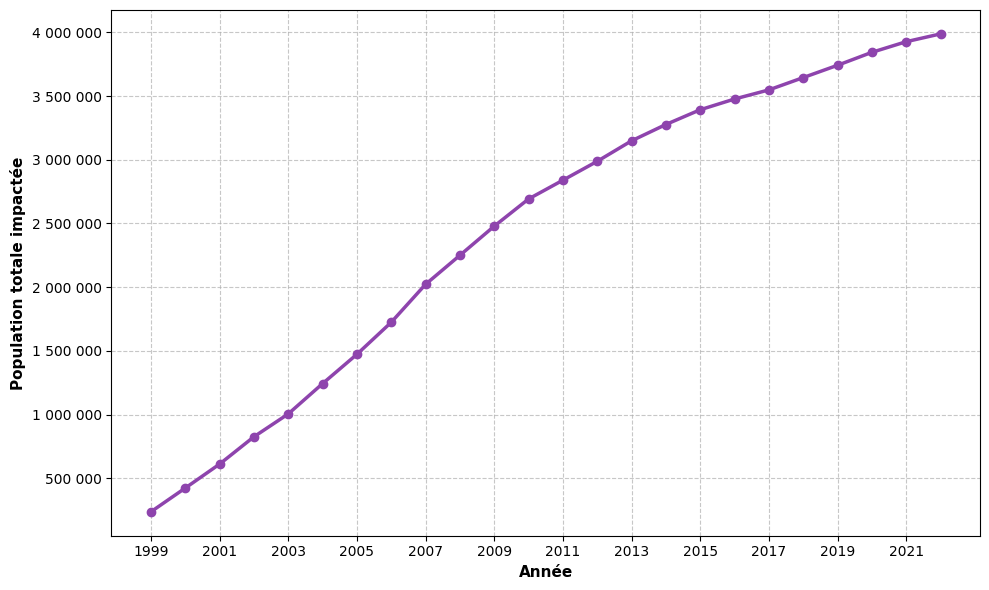

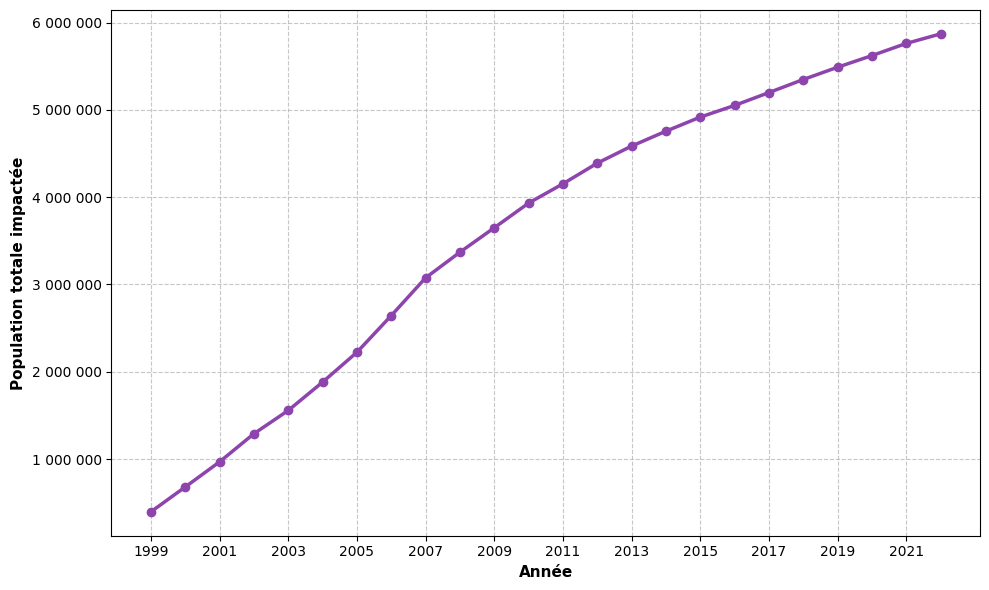

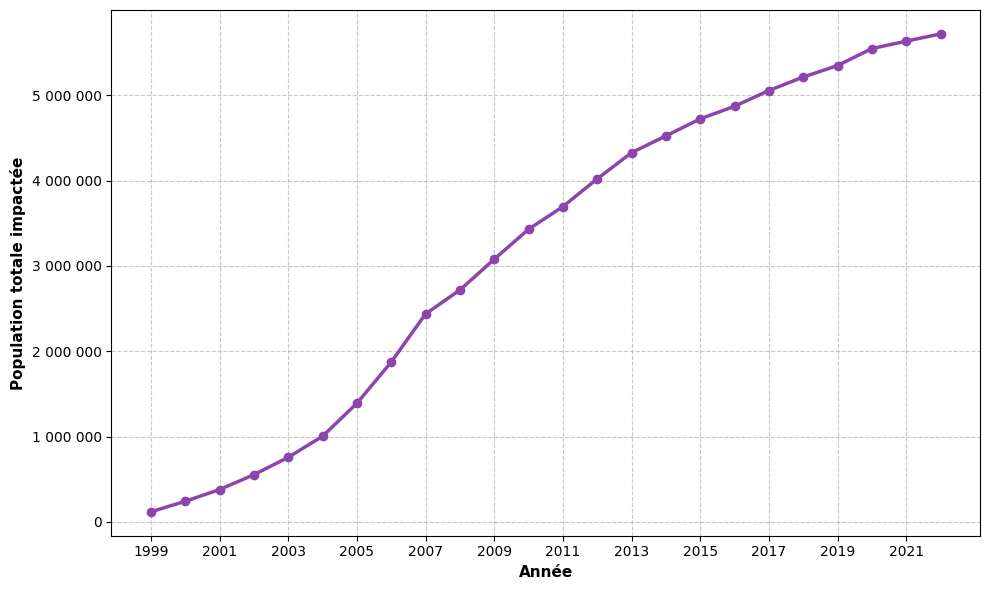

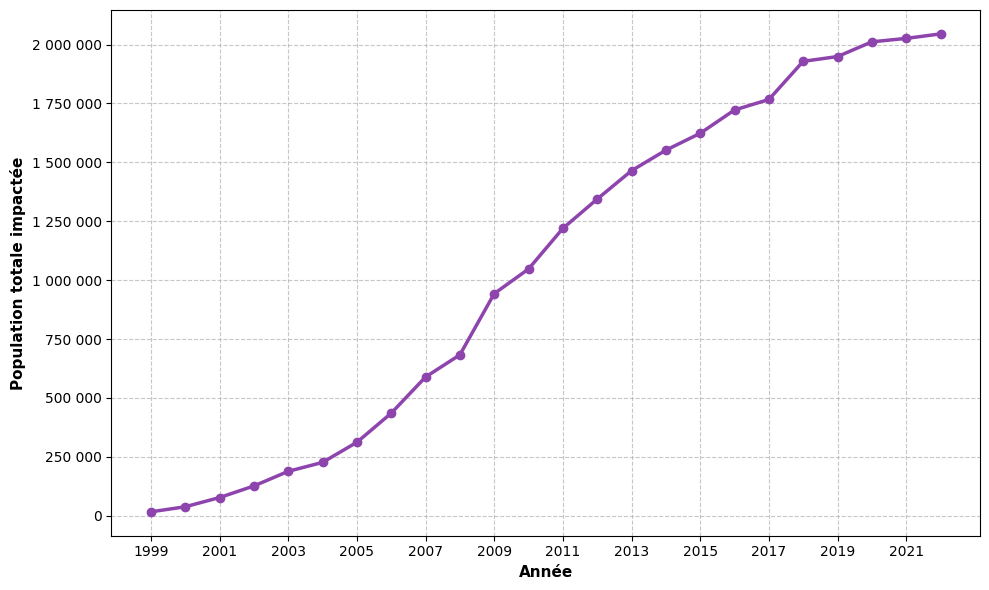

In [56]:
graphique_perte_equipements_cumulee(df_rnp)
graphique_perte_equipements_cumulee(df_rp)
graphique_perte_equipements_cumulee(df_ui)
graphique_perte_equipements_cumulee(df_ud)